# Surrogate Modeling for Inverse Parameter Estimation


## 1. Introduction
Inverse problems in computational mechanics often require repeated evaluations of expensive forward models.  
When the underlying system is governed by time-dependent PDEs, this quickly becomes computationally prohibitive.

In this notebook, we address this challenge by combining:
- **surrogate modeling** (to reduce computational cost)
- **statistical inference** (to estimate unknown parameters)

---

## Problem description

We consider a simplified model of sidewalk deformation under a pedestrian load.

The system is described by a **time-dependent linear elasticity problem** on a two-dimensional domain.  
The material has a layered structure:
- a **soft upper layer**
- a **stiffer lower layer**

Two parameters define the system:
- $\delta$ \: controls the thickness of the upper layer (indicator of structural condition)
- $m$ : represents the pedestrian mass (controls the applied load)

The goal is to estimate:
$\mu$ = $(\delta, m)$
from indirect observations of the system response.

---

## Data and surrogate model

A dataset of precomputed simulations is available:
- each sample corresponds to a displacement field $u_\mu(t)$
- the solution is observed over time for different parameter values

Since evaluating the full-order model is expensive, we construct a **surrogate model** using an autoencoder-based architecture.

The surrogate approximates the mapping:
$(\mu, t) \mapsto u_\mu(t)$
and allows for fast evaluations while preserving the main dynamics of the system.

---

## Inverse problem

Instead of observing the full displacement field, we only have access to:
- the **average vertical deformation on the top boundary**
- measured at a few discrete time instants

Using these observations and the surrogate model, we estimate the unknown parameters with two approaches:

- **Frequentist approach**
  - parameter estimation via residual minimization / likelihood

- **Bayesian approach**
  - posterior inference using MCMC (Metropolis algorithm)

---

## Objective

This notebook shows how:
- surrogate modeling enables efficient approximation of complex systems
- inverse problems can be solved with limited observations
- frequentist and Bayesian methods provide complementary insights into parameter estimation and uncertainty

## Notation

- $ \mu = (\delta, m)$ : vector of unknown parameters
- $\delta$ : thickness parameter of the upper layer, related to sidewalk health
- $ m $: pedestrian mass
-  $u_\mu(t)$ : displacement field at time $ t $ for parameters $ \mu $
- $Q(u,t)$: average vertical deformation on the top boundary
- FOM: full-order model
- ROM / surrogate: reduced approximation of the full-order model

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
try:
     from dlroms import*
except:
     !pip install --no-deps git+https://github.com/NicolaRFranco/dlroms.git
     from dlroms import*

## 2. Dataset and Problem Setup

### Problem setup

We consider a dataset of simulated trajectories generated by a time-dependent elasticity model.  
Each sample is associated with a parameter vector $ \mu = (\delta, m) $, where $ \delta $ controls the sidewalk structure and $ m $ denotes the pedestrian mass.

The observable quantity used in the inverse problem is the average vertical deformation on the top boundary:
$
Q(u,t) = \int_{\Gamma_{\text{top}}} u_y(x,t)\,dx
$

In [ ]:
import gdown
gdown.download(id = "1jMzgW3fe0A1BRiX1O4jH0T7GGUqnqVar", output = "sidewalk.npz")
clc()

data = np.load("sidewalk.npz")
mu, u = data['mu'], data['u']

print(mu.shape, u.shape)

(100, 2) (100, 51, 3362)


In [ ]:
mesh = fe.unitsquaremesh(40, 40)
Vh = fe.space(mesh, 'CG', 1, vector_valued = True)
clc()

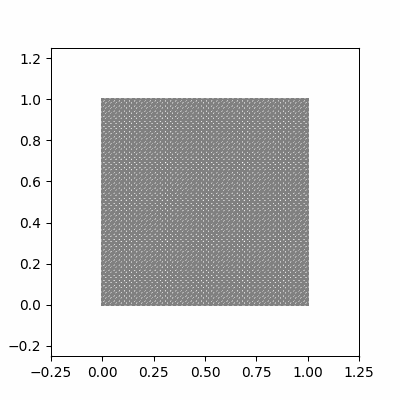

In [ ]:
# Visualization of the first simulation in the dataset
fe.animate(u[0], Vh, warp = True, axis = [-0.25, 1.25, -0.25, 1.25])

In [ ]:
ns, nt, nh = u.shape
indexes = 1-fe.dofs(Vh)[:, 1]<1e-12   # indexes of the dofs located at the top edge
tindex = np.arange(0, 51, 10)         # indexes of the times t_1, ..., t_q

def Q(u):
  """Given a space-time solution u, returns [Q(u,t_1), ..., Q(u, t_q)].
  If multiple solutions are passed, the output is computed batchwise.

  Works both on numpy arrays and torch tensors."""

  U = u.reshape(-1, nt, nh)[:, :, indexes]
  vals = U.reshape(-1, nt, np.sum(indexes)//2, 2)[:, :, :, 1].mean(axis = -1)[:, tindex]
  return vals if len(U)>1 else vals[0]

In [ ]:
Q(u[0]) # Example

array([ 0.00000000e+00, -9.27910484e-02, -5.47814538e-02,  1.09186950e-02,
       -1.32852061e-02,  8.07099377e-05])

In [ ]:
# Measurements available for inverse UQ
gdown.download(id = "1H51m5HL1RC0PDxnrM-q6YGjJjfbM6cC5", output = "surface_measurements.npy")
clc()

measurements = np.load("surface_measurements.npy")
measurements

array([ 0.01079223, -0.10217915, -0.07301079,  0.00097444, -0.00993845,
        0.00946097])

## 3. Surrogate Model

### Data splitting and surrogate modeling

The dataset is divided into two subsets:
- 75 simulations are used for training  
- 25 simulations are reserved for testing  

The goal is to construct a surrogate model approximating the parametric solution map:
$
(\mu, t) \mapsto u_\mu(t)
$

where $ \mu = (\delta, m)$  denotes the model parameters and $ u_\mu(t) $ is the corresponding time-dependent displacement field.

The surrogate is trained on the training set and evaluated on unseen test simulations.

---

### Error metric

The performance of the surrogate model is assessed using the following relative error:

$
\frac{1}{N_{\text{test}}}
\sum_{i=1}^{N_{\text{test}}}
\left[
\frac{
\sum_{j=1}^{N_t}
\|u_{i,j}^{\text{test}} - \tilde{u}_{i,j}^{\text{test}}\|_{L^2(\Omega)}
}{
\sum_{j=1}^{N_t}
\|u_{i,j}^{\text{test}}\|_{L^2(\Omega)}
}
\right]
$

where:
- $ u_{i,j}^{\text{test}} $ is the reference solution at time step \( j \) for test sample \( i \)
-  $\tilde{u}_{i,j}^{\text{test}}$  is the corresponding surrogate prediction
-  $N_t$  is the number of time steps
- $ N_{\text{test}} $ is the number of test simulations

This metric measures the average relative reconstruction error over the test set.

### Data preprocessing and tensor construction

The dataset is converted into tensor format in order to be used as input for the neural network.

Let:
- $ \mu \in \mathbb{R}^p $ denote the model parameters  
- $ u_\mu(t) \in \mathbb{R}^{n_h} $ denote the solution at time $ t $

The original data consists of trajectories indexed by:
- simulation index $ i = 1, \dots, N $
- time index $ j = 1, \dots, N_t $

To train the surrogate model, we construct an input tensor that explicitly includes both:
- the parameters $ \mu $
- the time variable $ t $

For each simulation and each time step, we define:
$
(\mu, t) \in \mathbb{R}^{p+1}
$

This results in a tensor `mut` of shape:
$
(N, N_t, p+1)
$

where each entry corresponds to a parameter-time pair.

In [ ]:
from dlroms import*
mu, u = dv.tensor(data['mu']), dv.tensor(data['u'])

ndata, ntimes, nh = u.shape
p = mu.shape[-1]
print("Trajectories:\t%d." % ndata)
print("Timesteps:\t%d." % ntimes)
print("FOM dimension:\t%d." % nh)
print("Parameters:\t%d." % p)

mut = dv.zeros(ndata, ntimes, p+1)
times = dv.tensor(np.linspace(0, 3.5, ntimes))
for i in range(ndata):
    mut[i,:,:2] = mu[i]
    mut[i,:, 2] = times

Trajectories:	100.
Timesteps:	51.
FOM dimension:	3362.
Parameters:	2.


In [ ]:
u = u.reshape(-1, nh)
mut = mut.reshape(-1, p+1)

### Reshaping (flattening)

To train the neural network, the data is reshaped so that each row corresponds to a single sample.

In particular:
- each sample represents a specific pair $ (\mu_i, t_j) $
- the corresponding output is $ u_{\mu_i}(t_j) $

After reshaping:
- the input tensor has shape $ (N \cdot N_t,\, p+1) $
- the output tensor has shape $ (N \cdot N_t,\, n_h) $

This transformation allows us to treat the problem as a standard supervised learning task, where:
- inputs: parameter-time pairs $ (\mu, t) $
- outputs: solution snapshots $ u_\mu(t) $

In [ ]:
l2 = L2(Vh)
l2.to(dv)
clc()

ntrain = 75*ntimes

def error(utrue, upred):
    return (l2(utrue-upred).reshape(-1, ntimes).sum(axis = -1)/l2(utrue).reshape(-1, ntimes).sum(axis = -1)).mean()

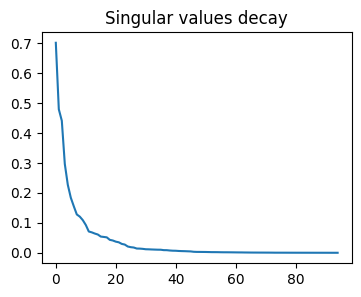

In [ ]:
# Preliminary check to see if we actually need autoencoders!
from scipy.linalg import svdvals

s = svdvals(u[:ntrain].T.cpu().numpy())
plt.figure(figsize = (4, 3))
plt.plot(s[5:100])
plt.title("Singular values decay")
plt.show()

The slow decay of the singular values indicates that the solution manifold is not well-approximated by a low-dimensional linear subspace.  
This highlights the limitations of linear dimensionality reduction techniques such as POD.

To capture the underlying nonlinear structure of the data, we adopt an autoencoder-based approach, which provides a nonlinear reduced representation of the solution space.

The latent dimension  $n$ is chosen according to the rule:
$p + 1 \leq n \leq 2(p + 1)$ where  $p$  is the number of parameters.

In [ ]:
latent = 7 # latent dimension
encoder = Dense(nh, 50) + Dense(50, latent)
decoder = Dense(latent, 50) + Dense(50, 100) + Dense(100, nh, activation = None)
autoencoder = DFNN(encoder + decoder)

autoencoder.He() #weight initialitation
autoencoder.to(dv) #move the model to the same enviroment of parameters
autoencoder.train(u, u, ntrain = ntrain, epochs = 500, loss = mse(l2), error = error, notation = '%')
autoencoder.freeze() #fix the weight so we can evaluate the NN

		Train	Test
Epoch 500:	3.67%	3.57%.

>> ETA: 0.09s.


Training complete. Elapsed time: 43.86 seconds.


In [ ]:
num2p(error(u[ntrain:], autoencoder(u[ntrain:]))) #test the error of autoencoder on test set


'3.57%'

Since time is included as an input variable, we enrich its representation using Fourier features.  
This allows the model to better capture temporal patterns and improves the expressiveness of the surrogate model.

In particular, we apply a Fourier feature mapping to the time component before passing the input to the neural network.

In [ ]:
from dlroms.dnns import Fourier
nu = encoder(u)

fmodes = 10
phi = DFNN(Fourier(fmodes, which = [2]) + Dense(p+1+2*fmodes, 100, gelu) + Dense(100, latent, None))

phi.He()
phi.to(dv)
phi.train(mut, nu, ntrain = ntrain, epochs = 300, loss = mse(euclidean))
phi.freeze()

		Train		Test
Epoch 300:	5.36e-05	5.07e-05.

>> ETA: 0.28s.


Training complete. Elapsed time: 1 minutes 23.21 seconds.


In [ ]:
dlrom = lambda mt: decoder(phi(mt))
num2p(error(u[ntrain:], dlrom(mut[ntrain:]))) #test the error of the surrogate on the test set

'5.22%'

## 4. Efficiency Analysis

The full-order model (FOM) requires approximately 8 seconds to generate a single trajectory, making repeated evaluations computationally expensive.

We compare the computational cost of the FOM and the surrogate model (ROM) by measuring the time required to generate a trajectory and computing the corresponding speed-up.

In [ ]:
from time import perf_counter
mu0 = dv.tensor([-3, 0.75])

mu0t = dv.zeros(ntimes, p+1)
mu0t[:, 2] = times
mu0t[:, :2] = mu0

t0 = perf_counter()
uROM = dlrom(mu0t)
t1 = perf_counter()
print("DL-ROM simulation time: %.3fs." % (t1-t0))
print(f"speed-up: {8 / (t1-t0):.2f}")

DL-ROM simulation time: 0.002s.
speed-up: 3618.71


## 5. Inverse Problem

### 5.1 Frequentist approach

Using the surrogate model, we estimate the parameters $ \mu = (\delta, m) $ by minimizing the discrepancy between observed and predicted quantities.

In particular, we consider the mapping:
$
u \mapsto [Q(u,t_1), \dots, Q(u,t_q)]^\top
$
and solve a residual minimization (maximum likelihood) problem to obtain point estimates of the parameters.

In [ ]:
from scipy.optimize import minimize
mu0=np.array([0.7,1])
def RSS_ROM(mu):
  #Add the time parameter for the NN
  mu=dv.tensor(mu)
  mut = dv.zeros(ntimes, p+1)
  mut[:, 2] = times
  mut[:, :2] = mu
  #Solution computation through the surrogate
  u_ROM = dlrom(mut)
  #Conversion in numpy array for Q
  u_ROM = u_ROM.cpu().numpy()
  #Computation of Q
  q=Q(u_ROM)
  #Error with the true measurements
  d=np.sum((q-measurements)**2)
  return d

mu_MLE_tilde = minimize(RSS_ROM, x0 = mu0, method='Powell').x
mu_MLE_tilde

array([0.76712042, 1.29147537])

In [ ]:
#Approximation of sigma
n, q = len(measurements), 1
p = mu.shape[-1]
sigma2 = RSS_ROM(mu_MLE_tilde)/(n*q-p)
print(sigma2)

0.0001551534313469441


### Frequentist confidence intervals and Jacobian computation

To construct frequentist confidence intervals, we need to compute the Jacobian of the measurement map.

In our setting, the model is a composition:
$
\mathcal{F}(\mu, t) = Q(\text{DLROM}(\mu, t))
$

While PyTorch's autograd can handle derivatives of neural networks, this requires the entire computation to remain inside the computational graph.  
For this reason:
- the operator $ Q $ must be implemented in PyTorch (no NumPy operations)
- the input is extended to include time, leading to a time-dependent parameter vector  $(\mu, t)$

This ensures that gradients can be computed correctly for the full composite mapping.

In [ ]:
import torch

def Q_torch(u, indexes, tindex, nt, nh):
    if u.dim() == 2:
        u = u.unsqueeze(0)

    U = u.reshape(-1, nt, nh)[:, :, indexes]
    U_xy = U.reshape(U.shape[0], nt, U.shape[-1] // 2, 2)
    Uy   = U_xy[..., 1]
    q    = Uy.mean(dim=-1)[:, tindex]

    return q[0] if q.shape[0] == 1 else q

In [ ]:

# n = number of scalar observations
# q = output dimension of Q
n, q = len(measurements), 1
p = mu.shape[-1]

theta_hat = dv.tensor(mu_MLE_tilde).reshape(-1)          # (p,)
meas_t    = dv.tensor(measurements).reshape(-1)          # (n,)

def measurements_map(theta):
    """
    theta: (p,) torch tensor
    returns: (n,) torch tensor of predicted measurements (QoI sampled at n instants)
    """
    theta = theta.reshape(-1)

    ntimes = times.numel()
    mut = dv.zeros(ntimes, p + 1)
    mut[:, :p] = theta.unsqueeze(0).expand(ntimes, p)
    mut[:,  p] = times

    u_rom = dlrom(mut)

    yhat = Q_torch(u_rom, indexes, tindex, nt, nh).reshape(-1)
    return yhat

def residual(theta):
    return (measurements_map(theta) - meas_t)            # (n,)

# RSS at theta_hat
r_hat = residual(theta_hat)
RSS = torch.dot(r_hat, r_hat)

# sigma^2 = RSS/(n*q - p) with q=1
dof = max(n * q - p, 1)
sigma2 = RSS / dof

J = torch.autograd.functional.jacobian(residual, theta_hat, create_graph=False)
J = J.reshape(n, p)

JTJ = J.T @ J
cov = sigma2 * torch.linalg.pinv(JTJ)

# standard errors and 90% CI
se = torch.sqrt(torch.diag(cov).clamp_min(0))
z = torch.distributions.Normal(0.0, 1.0).icdf(dv.tensor(0.90))
ci_lower = theta_hat - z * se
ci_upper = theta_hat + z * se

# numpy outputs
cov_np = cov.detach().cpu().numpy()
se_np  = se.detach().cpu().numpy()
ciL_np = ci_lower.detach().cpu().numpy()
ciU_np = ci_upper.detach().cpu().numpy()
sigma2 =sigma2.detach().cpu().numpy()


In [ ]:
print("Confidence interval for delta:",ciL_np[0],mu_MLE_tilde[0],ciU_np[0])
print("Confidence interval for m:",ciL_np[1],mu_MLE_tilde[1],ciU_np[1])

Confidence interal for delta: 0.5230359 0.767120423045008 1.011205
Confidence interal for m: 0.37490034 1.2914753652181648 2.2080505


### 5.2 Bayesian approach

We now estimate the parameters $\delta$  and  $m$  within a Bayesian framework.

Unlike the frequentist approach, which provides point estimates, the Bayesian approach models uncertainty by computing the posterior distribution of the parameters given the observations.

In [ ]:
def metropolis(nsim, mu0, prior, proposal_sampler, RSS, sigma2):
    """
    Run the Metropolis MCMC algorithm with a specified prior and proposal.

    Parameters:
    - nsim:      (int)           number of MCMC simulations
    - mu0:       (numpy.ndarray) initial state of the chain (e.g., MLE estimate)
    - prior:     (function)      model prior
    - RSS:       (function)      function computing the residual sum of squares (data misfit)
    - sigma2:    (float)         noise variance

    Returns:
    - chain: MCMC chain of sampled parameters
    - accept_rate: Acceptance rate of the MCMC algorithm
    """
    chain = np.zeros((nsim, len(mu0)))
    chain[0, :] = mu0
    rej = 0
    rss = RSS(mu0)

    for i in range(nsim-1):
        current = chain[i, :]
        candidate = proposal_sampler(current)
        rss_new = RSS(candidate)
        # Metropolis acceptance ratio
        ratio = np.exp(-0.5 * (rss_new - rss) / sigma2)*prior(candidate)/prior(current)
        if np.random.rand() < ratio:  # Accept proposal
            chain[i+1, :] = candidate
            rss = rss_new
        else:  # Reject proposal
            chain[i+1, :] = current
            rej += 1

    accept_rate = 1 - rej / nsim
    return chain, accept_rate

When defining the covariance of the Gaussian proposal distribution, it is important to account for the admissible range of the parameters.

If the covariance is too large, proposed samples are more likely to fall outside the valid parameter domain or in low-probability regions, leading to a high rejection rate and inefficient sampling.

In [ ]:
improper_prior = lambda x: float((0.5 <= x[0] <= 0.9) and (0.5 <= x[1] <= 1.5))
proposal_sampler = lambda x: np.random.multivariate_normal(mean = x, cov = np.diag([2*1e-3, 2*1e-2]))


chain, acceptance_rate = metropolis(20000, mu_MLE_tilde, improper_prior, proposal_sampler, RSS_ROM, sigma2)


In [ ]:
acceptance_rate


0.5136000000000001

## 6. Results

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_8269/1931512481.py:1: SyntaxWarning: invalid escape sequence '\d'
  params = ["$\delta$", "$m$"]


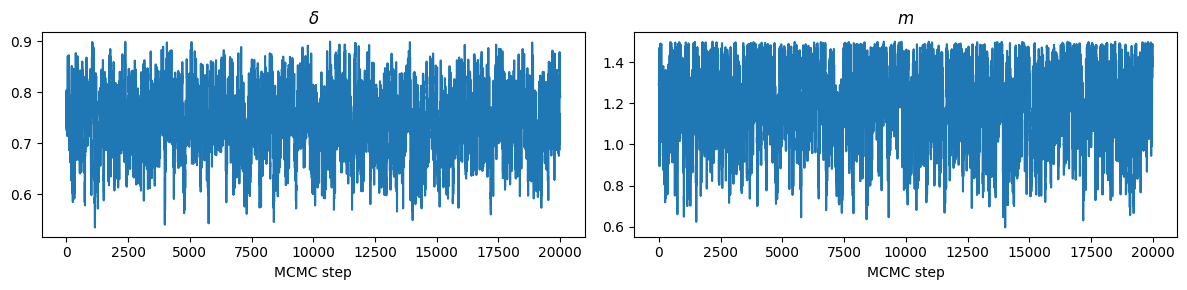

In [ ]:
params = ["$\delta$", "$m$"]
plt.figure(figsize = (12, 3))
for i in range(chain.shape[-1]):
  plt.subplot(1, p, i+1)
  plt.plot(chain[:, i])
  plt.title(params[i])
  plt.xlabel("MCMC step")
plt.tight_layout()

In [ ]:
b = 0
lag = 100
autocorrelation = np.stack([np.corrcoef(chain[b:-lag, i], chain[b+lag:, i])[0, 1] for i in range(chain.shape[-1])])
autocorrelation

array([-0.01860471, -0.0037252 ])

In [ ]:
posterior_samples = chain[b::lag]
posterior_samples.shape

(200, 2)

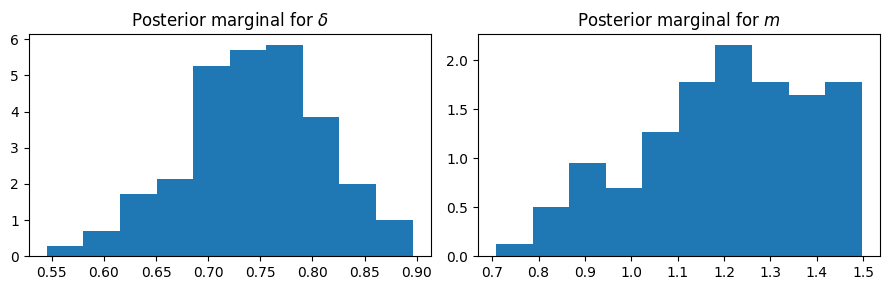

In [ ]:
plt.figure(figsize = (9, 3))
for i in range(chain.shape[-1]):
  plt.subplot(1, p, i+1)
  plt.hist(posterior_samples[:, i], bins = 10, density = True)
  plt.title("Posterior marginal for %s" % params[i])
plt.tight_layout()

In [ ]:
print(posterior_samples[:,0].mean())
print(posterior_samples[:,1].mean())
delta_mean=posterior_samples[:,0].mean()
m_mean=posterior_samples[:,1].mean()
mu_f=np.array([delta_mean,m_mean])

0.7444262897864584
1.2021433640474437


In [ ]:
print("90%s credibility interval for delta:\t[%.3f, %.3f]" % ("%", *np.quantile(posterior_samples[:, 0], [0.05, 0.95])))
print("90%s credibility interval for m:\t[%.3f, %.3f]" % ("%", *np.quantile(posterior_samples[:, 1], [0.05, 0.95])))

90% credibility interval for delta:	[0.627, 0.847]
90% credibility interval for m:	[0.880, 1.471]


## 7. Conclusions
The **frequentist approach** is sub-optimal in this scenario due to the extremely limited dataset ($n=6$). As a **point estimator**, the Maximum Likelihood Estimate (MLE) is highly susceptible to **overfitting the noise** inherent in the sparse observations, potentially leading to physically inconsistent parameter values.

Furthermore, the standard **asymptotic properties** of the MLE do not hold. The classical result:

$$\hat{\boldsymbol{\mu}}_{MLE} \sim \mathcal{N}(\boldsymbol{\mu}_*, \; \mathcal{I}(\boldsymbol{\mu}_*)^{-1})$$

where $\boldsymbol{\mu}_*$ is the true parameter vector and $\mathcal{I}$ is the **Fisher Information Matrix**, is a "large-sample" limit theorem ($n \to \infty$). With only 6 data points, the distribution of the estimator may be significantly skewed or biased, and the **Gaussian approximation** used for constructing confidence intervals becomes unreliable.

While MLE relies on **large-sample asymptotics** ($n \to \infty$) for its optimality, the **Metropolis-Hastings algorithm** is more robust when dealing with sparse datasets ($n=6$).

The advantages are twofold:
1. **Convergence in Distribution:** The MCMC approach provides an asymptotic guarantee regarding the **number of iterations**, ensuring that the chain converges to the exact posterior distribution $P(\mu | y)$ regardless of the sample size. It provides a full characterization of uncertainty rather than a potentially biased point estimate.
2. **Prior Integration:** We can formally incorporate **a priori physical knowledge** through the prior distribution $P(\mu)$. This acts as a regularizer, preventing the model from over-fitting the noise in the 6 observations and guiding the posterior toward physically consistent parameter space.